In [1]:
# Block 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [3]:
# Block 2: Generate Simulated Power Plant Data
np.random.seed(42)
days = 30
hours = days * 24

timestamps = [datetime(2026, 2, 1) + timedelta(hours=i) for i in range(hours)]

data = {
    'Timestamp': timestamps,
    'Power_Output_MW': np.random.normal(450, 50, hours).clip(300, 600),
    'Temperature_C': np.random.normal(520, 30, hours).clip(400, 650),
    'Fuel_Consumption_ton': np.random.normal(120, 15, hours).clip(80, 180),
    'Efficiency_%': np.random.normal(85, 5, hours).clip(70, 95),
}

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Timestamp']).dt.date

print("✅ Data Generated Successfully!")
print(f"📊 Total Records: {len(df)}")
print(f"📅 Period: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print("\n--- Sample Data ---")
print(df.head())

✅ Data Generated Successfully!
📊 Total Records: 720
📅 Period: 2026-02-01 00:00:00 to 2026-03-02 23:00:00

--- Sample Data ---
            Timestamp  Power_Output_MW  Temperature_C  Fuel_Consumption_ton  \
0 2026-02-01 00:00:00       474.835708     529.234053            129.943219   
1 2026-02-01 01:00:00       443.086785     468.694948            137.602108   
2 2026-02-01 02:00:00       482.384427     479.554437            122.715323   
3 2026-02-01 03:00:00       526.151493     542.297923            100.547521   
4 2026-02-01 04:00:00       438.292331     525.125963            125.995319   

   Efficiency_%        Date  
0     79.442710  2026-02-01  
1     86.232524  2026-02-01  
2     87.491109  2026-02-01  
3     90.700745  2026-02-01  
4     92.902703  2026-02-01  


In [5]:
# Block 3: Data Analysis & Key Metrics
print("=" * 50)
print("   POWER PLANT PERFORMANCE REPORT")
print("=" * 50)

avg_power = df['Power_Output_MW'].mean()
max_power = df['Power_Output_MW'].max()
min_power = df['Power_Output_MW'].min()
avg_efficiency = df['Efficiency_%'].mean()
avg_temp = df['Temperature_C'].mean()
total_fuel = df['Fuel_Consumption_ton'].sum()

print(f"\n⚡ Average Power Output  : {avg_power:.2f} MW")
print(f"🔺 Peak Power Output     : {max_power:.2f} MW")
print(f"🔻 Minimum Power Output  : {min_power:.2f} MW")
print(f"🌡  Average Temperature   : {avg_temp:.2f} °C")
print(f"📈 Average Efficiency    : {avg_efficiency:.2f} %")
print(f"⛽ Total Fuel Consumed   : {total_fuel:.2f} tons")

# Anomaly Detection - flag low efficiency hours
anomalies = df[df['Efficiency_%'] < 75]
print(f"\n⚠️  Low Efficiency Alerts : {len(anomalies)} hours flagged")
print("=" * 50)

   POWER PLANT PERFORMANCE REPORT

⚡ Average Power Output  : 449.45 MW
🔺 Peak Power Output     : 600.00 MW
🔻 Minimum Power Output  : 300.00 MW
🌡  Average Temperature   : 522.69 °C
📈 Average Efficiency    : 85.09 %
⛽ Total Fuel Consumed   : 86712.85 tons

⚠️  Low Efficiency Alerts : 10 hours flagged


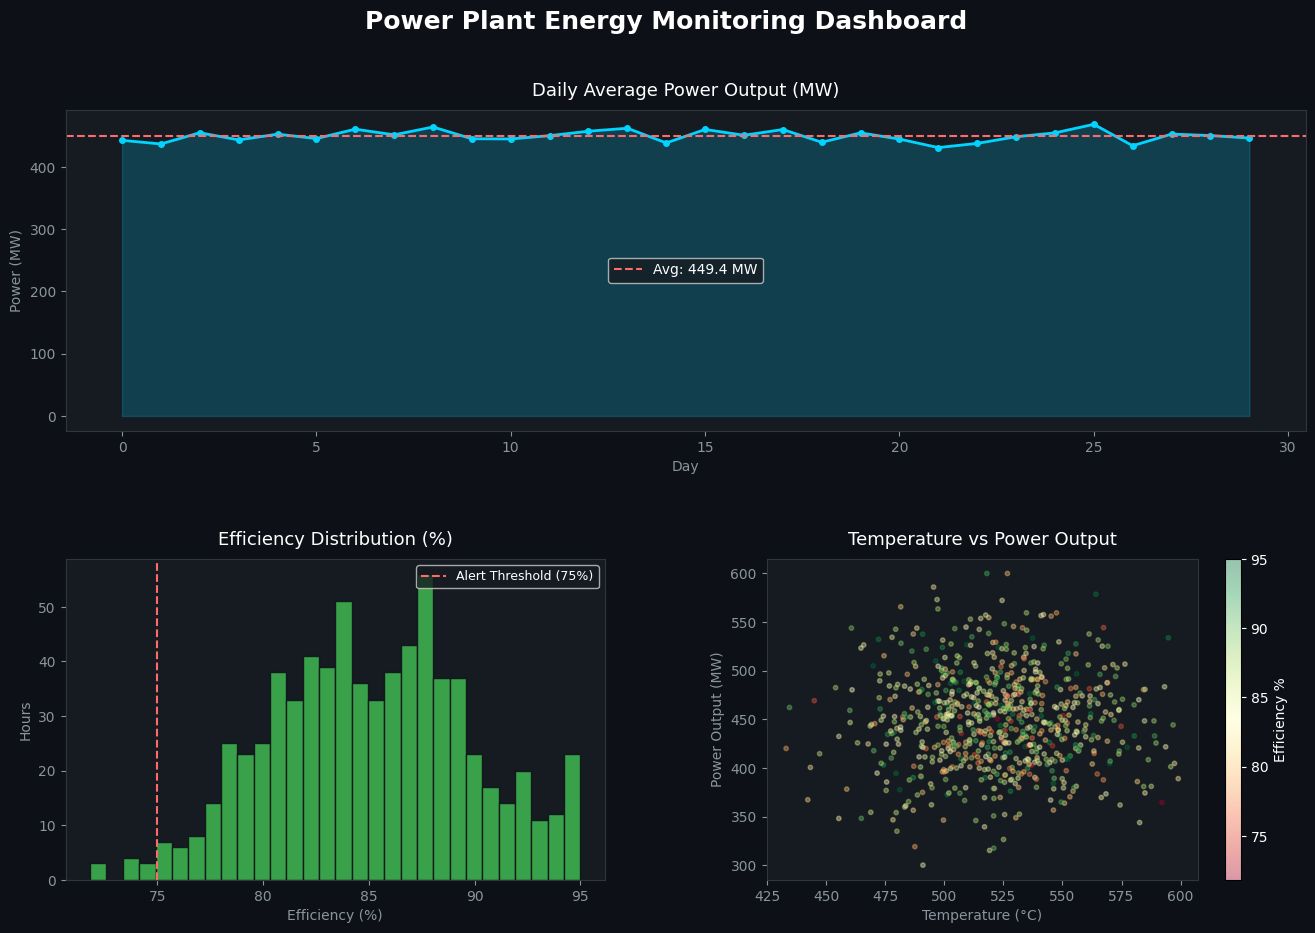

✅ Dashboard saved as 'power_plant_dashboard.png'


In [6]:
# Block 4: Power Plant Energy Monitoring Dashboard
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

plt.suptitle('Power Plant Energy Monitoring Dashboard',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# --- Plot 1: Power Output Over Time ---
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#161b22')
daily_power = df.groupby('Date')['Power_Output_MW'].mean()
ax1.plot(range(len(daily_power)), daily_power.values,
         color='#00d4ff', linewidth=2, marker='o', markersize=4)
ax1.axhline(y=avg_power, color='#ff6b6b', linestyle='--',
            linewidth=1.5, label=f'Avg: {avg_power:.1f} MW')
ax1.fill_between(range(len(daily_power)), daily_power.values,
                 alpha=0.2, color='#00d4ff')
ax1.set_title('Daily Average Power Output (MW)', color='white', fontsize=13, pad=10)
ax1.set_xlabel('Day', color='#8b949e')
ax1.set_ylabel('Power (MW)', color='#8b949e')
ax1.tick_params(colors='#8b949e')
ax1.legend(fontsize=10, facecolor='#161b22', labelcolor='white')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363d')

# --- Plot 2: Efficiency Distribution ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#161b22')
ax2.hist(df['Efficiency_%'], bins=30, color='#3fb950',
         edgecolor='#0d1117', alpha=0.85)
ax2.axvline(x=75, color='#ff6b6b', linestyle='--',
            linewidth=1.5, label='Alert Threshold (75%)')
ax2.set_title('Efficiency Distribution (%)', color='white', fontsize=13, pad=10)
ax2.set_xlabel('Efficiency (%)', color='#8b949e')
ax2.set_ylabel('Hours', color='#8b949e')
ax2.tick_params(colors='#8b949e')
ax2.legend(fontsize=9, facecolor='#161b22', labelcolor='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363d')

# --- Plot 3: Temperature vs Power Output ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#161b22')
scatter = ax3.scatter(df['Temperature_C'], df['Power_Output_MW'],
                      c=df['Efficiency_%'], cmap='RdYlGn',
                      alpha=0.4, s=10)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Efficiency %', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax3.set_title('Temperature vs Power Output', color='white', fontsize=13, pad=10)
ax3.set_xlabel('Temperature (°C)', color='#8b949e')
ax3.set_ylabel('Power Output (MW)', color='#8b949e')
ax3.tick_params(colors='#8b949e')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363d')

plt.savefig('power_plant_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Dashboard saved as 'power_plant_dashboard.png'")

In [7]:
# Block 5: Project Summary
print("=" * 55)
print("   PROJECT: Power Plant Energy Monitoring Dashboard")
print("   Author : Dinesh R")
print("   Tools  : Python, Pandas, NumPy, Matplotlib")
print("   Date   : March 2026")
print("=" * 55)
print("""
📌 Key Features:
   ✅ Simulated 720 hours (30 days) of plant sensor data
   ✅ Tracked Power Output, Temperature, Fuel & Efficiency
   ✅ Automated anomaly detection for low efficiency hours
   ✅ Visual dashboard with 3 analytical charts
   ✅ Saved dashboard as exportable PNG report
""")

   PROJECT: Power Plant Energy Monitoring Dashboard
   Author : Dinesh R
   Tools  : Python, Pandas, NumPy, Matplotlib
   Date   : March 2026

📌 Key Features:
   ✅ Simulated 720 hours (30 days) of plant sensor data
   ✅ Tracked Power Output, Temperature, Fuel & Efficiency
   ✅ Automated anomaly detection for low efficiency hours
   ✅ Visual dashboard with 3 analytical charts
   ✅ Saved dashboard as exportable PNG report

